In [ ]:
# DEEP LEARNING - CLASIFICADOR DE IMAGENES

In [36]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
from natsort import natsorted
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Input, MaxPooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


## Paso 1: Carga del conjunto de datos

In [22]:
train_dir = "/content/drive/MyDrive/dogs_vs_cats/train"
test_dir = "/content/drive/MyDrive/dogs_vs_cats/test"
dogs_dir = "/content/drive/MyDrive/dogs_vs_cats/train/dogs"
cats_dir = "/content/drive/MyDrive/dogs_vs_cats/train/cats"
print(os.listdir(cats_dir))


['cat.8851.jpg', 'cat.8834.jpg', 'cat.8925.jpg', 'cat.8954.jpg', 'cat.8949.jpg', 'cat.8923.jpg', 'cat.890.jpg', 'cat.894.jpg', 'cat.8946.jpg', 'cat.8922.jpg', 'cat.8958.jpg', 'cat.8924.jpg', 'cat.8919.jpg', 'cat.8975.jpg', 'cat.8916.jpg', 'cat.8970.jpg', 'cat.8973.jpg', 'cat.8890.jpg', 'cat.8895.jpg', 'cat.8931.jpg', 'cat.8956.jpg', 'cat.8894.jpg', 'cat.8940.jpg', 'cat.8965.jpg', 'cat.8914.jpg', 'cat.8932.jpg', 'cat.8959.jpg', 'cat.8906.jpg', 'cat.8910.jpg', 'cat.8961.jpg', 'cat.8901.jpg', 'cat.8903.jpg', 'cat.896.jpg', 'cat.8908.jpg', 'cat.8915.jpg', 'cat.8971.jpg', 'cat.8960.jpg', 'cat.897.jpg', 'cat.8896.jpg', 'cat.8957.jpg', 'cat.8934.jpg', 'cat.8976.jpg', 'cat.8968.jpg', 'cat.8939.jpg', 'cat.891.jpg', 'cat.8972.jpg', 'cat.8945.jpg', 'cat.8953.jpg', 'cat.893.jpg', 'cat.8929.jpg', 'cat.8904.jpg', 'cat.8964.jpg', 'cat.8933.jpg', 'cat.8900.jpg', 'cat.8947.jpg', 'cat.8937.jpg', 'cat.8921.jpg', 'cat.8951.jpg', 'cat.8941.jpg', 'cat.8944.jpg', 'cat.8969.jpg', 'cat.8930.jpg', 'cat.8920.jpg

In [ ]:
cats_dir

'/content/drive/MyDrive/dogs_vs_cats/train/cats'

# Paso 2: Visualizamos la información de entrada

In [ ]:
# Obtener los nombres de archivo .jpg en la carpeta cats
cat_images = natsorted([f for f in os.listdir(cats_dir)])
cat_images[:9]

['cat.0.jpg',
 'cat.1.jpg',
 'cat.2.jpg',
 'cat.3.jpg',
 'cat.4.jpg',
 'cat.5.jpg',
 'cat.6.jpg',
 'cat.7.jpg',
 'cat.8.jpg']

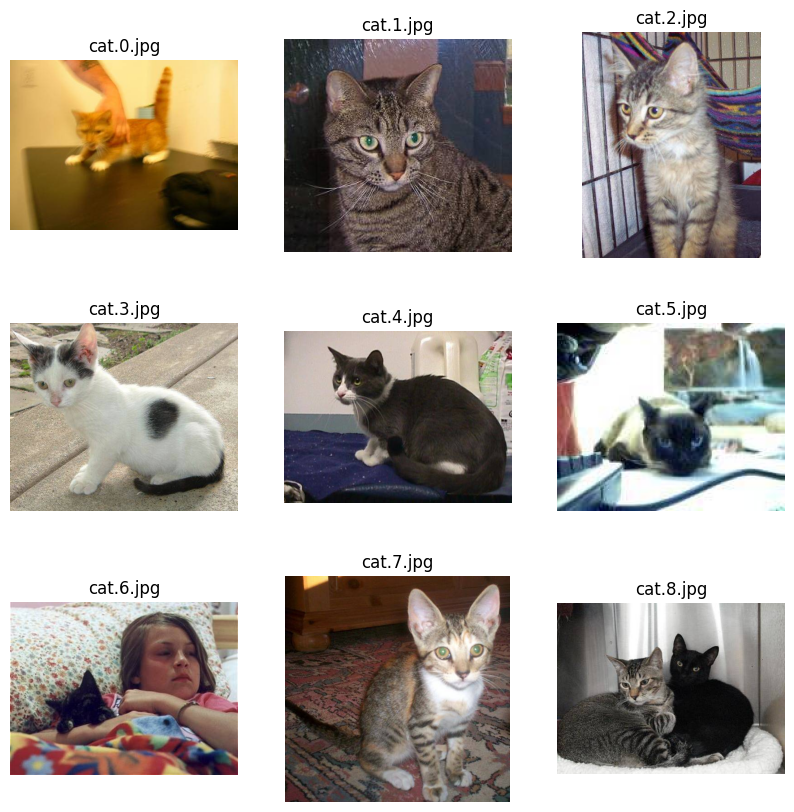

In [ ]:
# Mostramos las primeras 9 imágenes de gatos
plt.figure(figsize=(10, 10))

for i in range(9):
    img_path_cats = os.path.join(cats_dir, cat_images[i])
    img_cats = Image.open(img_path_cats)
    plt.subplot(3, 3, i+1)
    plt.imshow(img_cats)
    plt.title(cat_images[i])
    plt.axis('off')

plt.show()

In [ ]:
# Obtener los nombres de archivo .jpg de la carpeta dogs
dog_images = natsorted([f for f in os.listdir(dogs_dir)])
dog_images[:9]

['dog.0.jpg',
 'dog.1.jpg',
 'dog.2.jpg',
 'dog.3.jpg',
 'dog.4.jpg',
 'dog.6.jpg',
 'dog.7.jpg',
 'dog.8.jpg',
 'dog.10.jpg']

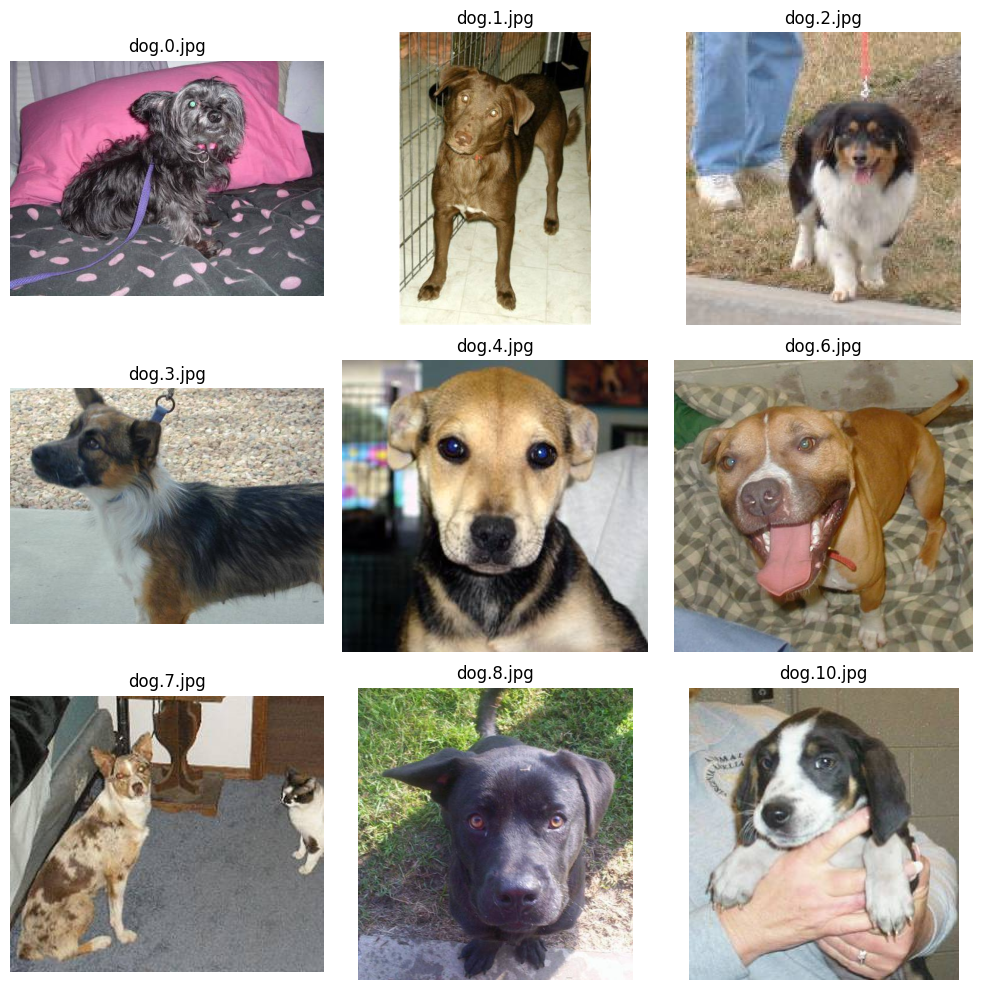

In [ ]:
# Mostramos las primeras 9 imágenes de perros
plt.figure(figsize=(10, 10))

for i in range (9):
  img_path_dogs = os.path.join(dogs_dir,dog_images[i])
  img_dogs = Image.open(img_path_dogs)
  img_dogs.show()
  plt.subplot(3, 3, i+1)
  plt.imshow(img_dogs)
  plt.title(dog_images[i])
  plt.axis('off')

plt.tight_layout()

In [27]:
# Creamos generador para datos de entrenamiento y prueba escalados
trdata_gen = ImageDataGenerator(rescale=1./255)
tsdata_gen = ImageDataGenerator(rescale=1./255)

In [28]:
# Cargamos imágenes convertidas a tamaño 200x200 de entrenamiento y prueba
trdata = trdata_gen.flow_from_directory(train_dir,
                                        target_size=(128,128),
                                        batch_size=32,
                                        class_mode='categorical',  # recomendable para units = 2, activation = "softmax" (etiquetas formato one-hot)
                                        shuffle=True)

tsdata = tsdata_gen.flow_from_directory(test_dir,
                                        target_size=(128,128),
                                        batch_size=32,
                                        class_mode='categorical',
                                        shuffle=False)


Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [ ]:
images, _= next(trdata)

images.shape

(32, 200, 200, 3)

In [ ]:
images, _ = next(tsdata)

images.shape

(32, 200, 200, 3)

# Paso 3: Construimos una RNA



In [29]:
# Modelo secuencial: se construye capa por capa
model = Sequential()

model.add(Input(shape=(128, 128, 3)))

model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))


In [30]:
# Configuramos y compilamos el modelo
model.compile(optimizer='Adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [31]:
history = model.fit(trdata, epochs=3)
# 48 min

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 2184s 3s/step - accuracy: 0.5893 - loss: 0.6615
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 375s 600ms/step - accuracy: 0.7297 - loss: 0.5395
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 373s 597ms/step - accuracy: 0.7743 - loss: 0.4780


In [34]:
history.history

{'accuracy': [0.6434000134468079, 0.7434999942779541, 0.7786999940872192],
 'loss': [0.6228124499320984, 0.522161602973938, 0.4714061915874481]}

In [32]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217,064 (12.27 MB)

 Trainable params: 1,072,354 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,144,710 (8.18 MB)

In [33]:
# 20 min
loss, acc = model.evaluate(tsdata)
loss, acc

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 1215s 8s/step - accuracy: 0.8574 - loss: 0.3593


(0.4428060054779053, 0.7925999760627747)

# Paso 4: Optimiza el modelo anterior


- ModelCheckpoint guarda automáticamente el mejor modelo
- EarlyStopping detiene el entrenamiento si no hay mejoras, ahorrando tiempo y evitando sobreentrenamiento

In [37]:
checkpoint = ModelCheckpoint(filepath='best_model.h5',
                             monitor='val_accuracy',
                             save_best_only=True,  # Solo guardar si mejora
                             mode='max',  # Para tener la mayor precision
                             verbose=1)  # Muestra mensaje cuando guarda

earlystop = EarlyStopping(monitor='val_loss',
                          patience=3,  # Epocas sin mejora antes de detener
                          restore_best_weights=True,  # Al final vuelve al mejor modelo
                          verbose=1)

In [ ]:
# Entrenamos el modelo con callbacks
history_opt= model.fit(trdata,
                       epochs=6,
                       callbacks=[checkpoint, earlystop])

Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 375s 599ms/step - accuracy: 0.8058 - loss: 0.4244
Epoch 2/6


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with val_accuracy available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


 16/625 ━━━━━━━━━━━━━━━━━━━━ 5:27 538ms/step - accuracy: 0.8466 - loss: 0.4104

In [ ]:
model.summary

In [ ]:
loss, accuracy = model.evaluate(tsdata)

In [ ]:
model.save('best_model.h5')